# Cesarean sections in Poland (2010-2025)

Data analysis project I made while learning data analysis and switching career from logistics.

I wanted to check how the cesarean section (C-section) rate changed in Poland over the years, if it's different between regions, and if bigger hospitals do more C-sections than small ones.

Data is public, from NFZ (Polish National Health Fund) - "Porody i opieka okołoporodowa 2010-2025" (births and perinatal care).

Plan:
1. load data and check if it's clean
2. how the C-section rate changed over time
3. differences between provinces (województwa)
4. which hospitals have highest / lowest rate
5. does hospital size matter?
6. simple regression model for the trend

Note - I'm not a doctor, this is just a data project, not medical advice or conclusions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

sns.set_style('whitegrid')
RANDOM_STATE = 42

## 1. Loading the data

The csv file has some extra rows at the top before the actual table starts (title, empty row, table name), so I need to skip first 3 rows. Also numbers in the file have extra spaces before them, so I use skipinitialspace.

In [2]:
df = pd.read_csv(
    '../data/porody_2010_2025.csv',
    sep=';',
    skiprows=3,
    encoding='utf-8-sig',
    skipinitialspace=True
)

df.head()

,Kod świadczeniodawcy,Nazwa świadczeniodawcy,Adres miejsca udzielania świadczeń,Województwo miejsca udzielania świadczeń,Rok,Miesiąc,KOC,Liczba porodów,Liczba cesarskich cięć,Liczba porodów zabiegowych,Liczba porodów samoistnych z nacięciem krocza,Liczba porodów samoistnych bez nacięcia krocza,Liczba porodów drogami natury,Liczba porodów drogami natury ze znieczuleniem
0,20002493,Novum-Med sp. z o.o.,"Więcbork, Mickiewicza 26",Kujawsko-pomorskie,2010,1,0,51,18,0,24,9,33,0
1,20002493,Novum-Med sp. z o.o.,"Więcbork, Mickiewicza 26",Kujawsko-pomorskie,2010,8,0,44,5,0,34,5,39,0
2,20002493,Novum-Med sp. z o.o.,"Więcbork, Mickiewicza 26",Kujawsko-pomorskie,2010,2,0,41,15,0,20,6,26,0
3,20002493,Novum-Med sp. z o.o.,"Więcbork, Mickiewicza 26",Kujawsko-pomorskie,2010,12,0,36,5,0,22,9,31,0
4,20002493,Novum-Med sp. z o.o.,"Więcbork, Mickiewicza 26",Kujawsko-pomorskie,2010,10,0,52,17,0,29,6,35,0


Column names are in Polish and pretty long, so I renamed them to shorter English names to make the code easier to read.

Original name -> new name:
- Kod świadczeniodawcy -> hospital_id
- Nazwa świadczeniodawcy -> hospital_name
- Adres miejsca udzielania świadczeń -> address
- Województwo miejsca udzielania świadczeń -> province
- Rok -> year
- Miesiąc -> month
- KOC -> koc
- Liczba porodów -> births_total
- Liczba cesarskich cięć -> births_cesarean
- Liczba porodów zabiegowych -> births_instrumental
- Liczba porodów samoistnych z nacięciem krocza -> births_natural_episiotomy
- Liczba porodów samoistnych bez nacięcia krocza -> births_natural_no_episiotomy
- Liczba porodów drogami natury -> births_vaginal
- Liczba porodów drogami natury ze znieczuleniem -> births_vaginal_anesthesia

In [3]:
df.columns = [
    'hospital_id', 'hospital_name', 'address', 'province', 'year', 'month', 'koc',
    'births_total', 'births_cesarean', 'births_instrumental',
    'births_natural_episiotomy', 'births_natural_no_episiotomy',
    'births_vaginal', 'births_vaginal_anesthesia'
]

df.shape

(70474, 14)

## 2. Checking the data

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70474 entries, 0 to 70473
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   hospital_id                   70474 non-null  str  
 1   hospital_name                 70474 non-null  str  
 2   address                       70474 non-null  str  
 3   province                      70474 non-null  str  
 4   year                          70474 non-null  int64
 5   month                         70474 non-null  int64
 6   koc                           70474 non-null  int64
 7   births_total                  70474 non-null  int64
 8   births_cesarean               70474 non-null  int64
 9   births_instrumental           70474 non-null  int64
 10  births_natural_episiotomy     70474 non-null  int64
 11  births_natural_no_episiotomy  70474 non-null  int64
 12  births_vaginal                70474 non-null  int64
 13  births_vaginal_anesthesia     70474 non-nu

In [5]:
# checking for missing values
df.isnull().sum()

hospital_id                     0
hospital_name                   0
address                         0
province                        0
year                            0
month                           0
koc                             0
births_total                    0
births_cesarean                 0
births_instrumental             0
births_natural_episiotomy       0
births_natural_no_episiotomy    0
births_vaginal                  0
births_vaginal_anesthesia       0
dtype: int64

In [6]:
df.describe()

,year,month,koc,births_total,births_cesarean,births_instrumental,births_natural_episiotomy,births_natural_no_episiotomy,births_vaginal,births_vaginal_anesthesia
count,70474.000000,70474.000000,70474.000000,70474.000000,70474.000000,70474.000000,70474.000000,70474.000000,70474.000000,70474.000000
mean,2017.097369,6.481454,0.054687,77.624486,33.235392,1.123563,22.783835,20.056446,44.389094,4.507804
std,4.543453,3.450258,0.227370,69.219036,31.777286,3.155216,23.300589,23.393736,41.877069,15.166615
min,2010.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2013.000000,3.000000,0.000000,34.000000,14.000000,0.000000,8.000000,7.000000,19.000000,0.000000
50%,2017.000000,6.000000,0.000000,56.000000,23.000000,0.000000,16.000000,14.000000,32.000000,0.000000
75%,2021.000000,9.000000,0.000000,99.000000,41.000000,1.000000,30.000000,25.000000,57.000000,1.000000
max,2025.000000,12.000000,1.000000,698.000000,314.000000,73.000000,314.000000,328.000000,443.000000,220.000000


In [7]:
# how many hospitals and provinces do we have, and what years
print('number of hospitals:', df['hospital_id'].nunique())
print('number of provinces:', df['province'].nunique())
print('years:', df['year'].min(), '-', df['year'].max())

number of hospitals: 419
number of provinces: 16
years: 2010 - 2025


In [8]:
# I want to check if cesarean + instrumental + vaginal births actually add up to total births
check_sum = df[['births_cesarean', 'births_instrumental', 'births_vaginal']].sum(axis=1)
diff = (check_sum - df['births_total']).abs()

print('biggest difference in one row:', diff.max())
print('rows with any difference:', (diff > 0).sum(), 'out of', len(df))

biggest difference in one row: 73
rows with any difference: 24757 out of 70474


The differences are tiny (max few dozen out of thousands of births in a row), so probably just small reporting mistakes from hospitals. I'm leaving these rows as they are, doesn't really change the overall picture.

In [9]:
# adding a column with % of cesarean births for every row
df['pct_cesarean'] = df['births_cesarean'] / df['births_total'] * 100

## 3. How did the C-section rate change over the years?

In [10]:
trend = df.groupby('year').agg(
    births_total=('births_total', 'sum'),
    births_cesarean=('births_cesarean', 'sum')
)
trend['pct_cesarean'] = trend['births_cesarean'] / trend['births_total'] * 100

trend

,births_total,births_cesarean,pct_cesarean
year,,,
2010,403214,136264,33.794462
2011,379742,134405,35.393767
2012,380322,141244,37.138004
2013,360232,143895,39.945091
2014,365309,155260,42.501006
2015,363424,157556,43.353218
2016,372936,162959,43.696237
2017,393275,172619,43.892696
2018,379559,170092,44.813059


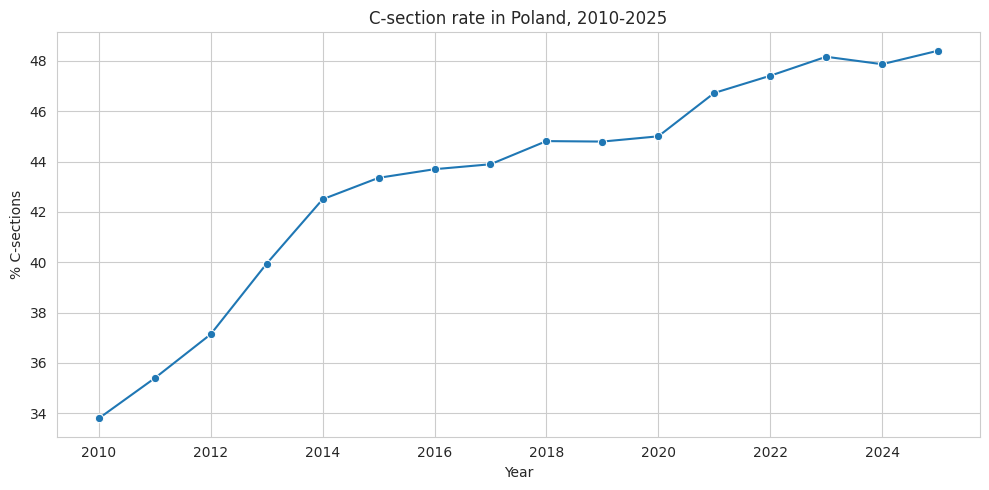

In [11]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=trend, x=trend.index, y='pct_cesarean', marker='o')

plt.title('C-section rate in Poland, 2010-2025')
plt.xlabel('Year')
plt.ylabel('% C-sections')
plt.tight_layout()
plt.show()

So the rate went up from about 34% in 2010 to almost 48% in 2025, that's +14 percentage points in 15 years, pretty big jump. Just for context, WHO usually says a medically justified rate is around 10-15%, so Poland is way above that (from what I read, a lot of other European countries are too, not just Poland).

## 4. Is there any monthly pattern? (seasonality)

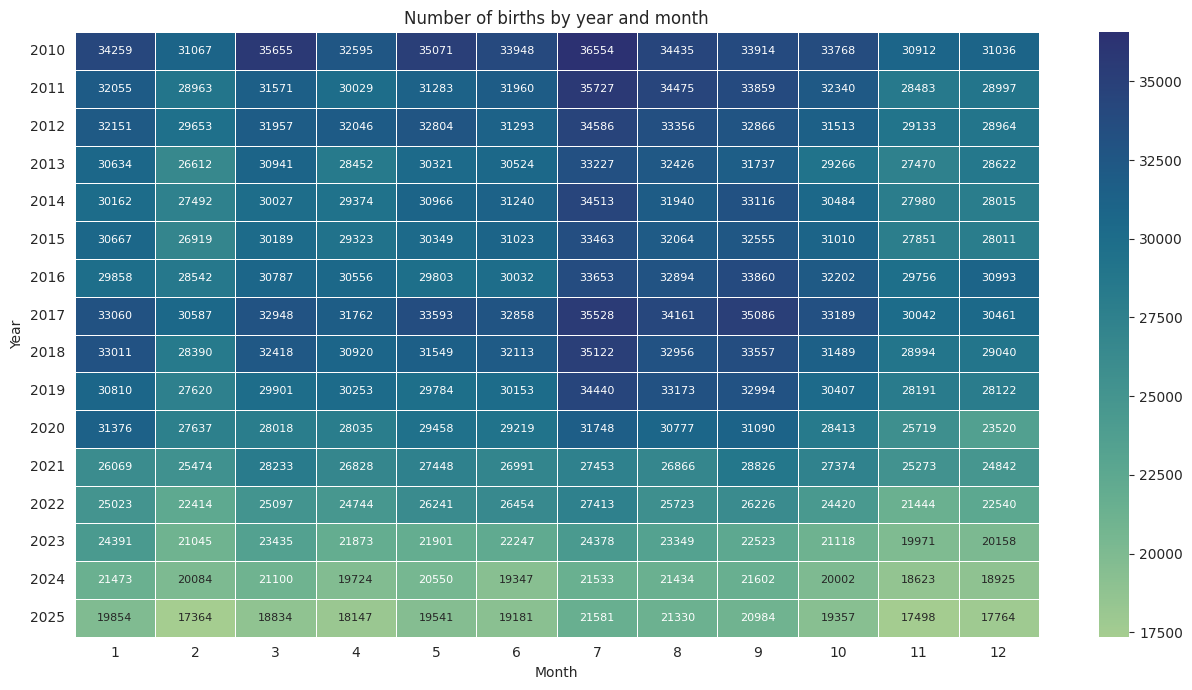

In [12]:
pivot = df.groupby(['year', 'month'])['births_total'].sum().unstack()

plt.figure(figsize=(13, 7))
sns.heatmap(pivot, cmap='crest', annot=True, fmt='.0f', annot_kws={'size': 8}, linewidths=0.5)

plt.title('Number of births by year and month')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

You can see the numbers get smaller year by year (rows at the bottom are lighter), which matches the general drop in birth rate in Poland. I don't really see a strong pattern within a year (like more births in some specific month), maybe a tiny bit but nothing major.

## 5. Differences between provinces

In [13]:
province_stats = df.groupby('province').agg(
    births_total=('births_total', 'sum'),
    births_cesarean=('births_cesarean', 'sum')
)
province_stats['pct_cesarean'] = province_stats['births_cesarean'] / province_stats['births_total'] * 100
province_stats = province_stats.sort_values('pct_cesarean', ascending=False)

province_stats

,births_total,births_cesarean,pct_cesarean
province,,,
Podkarpackie,295425,150881,51.072523
Podlaskie,163581,82342,50.337142
Łódzkie,323758,158839,49.061027
Świętokrzyskie,143845,70534,49.034725
Zachodniopomorskie,221036,103690,46.910910
Lubelskie,267335,123865,46.333252
Dolnośląskie,391928,178092,45.439979
Małopolskie,540371,245016,45.342182
Lubuskie,133690,59784,44.718378


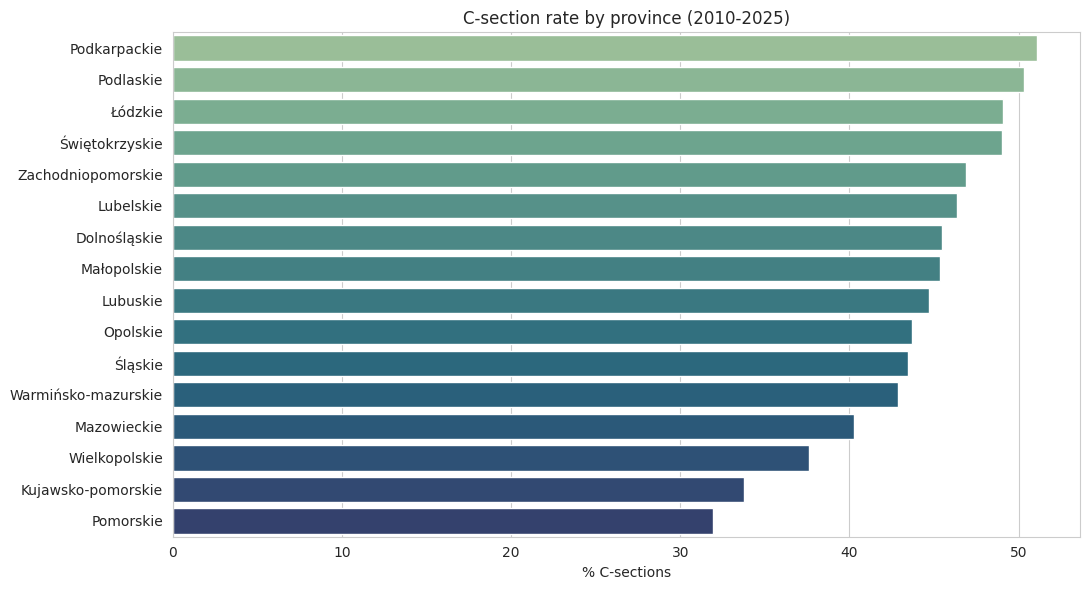

In [14]:
plt.figure(figsize=(11, 6))
sns.barplot(
    data=province_stats.reset_index(),
    x='pct_cesarean', y='province',
    hue='province', palette='crest', legend=False
)

plt.title('C-section rate by province (2010-2025)')
plt.xlabel('% C-sections')
plt.ylabel('')
plt.tight_layout()
plt.show()

There's a pretty big gap here - from about 32% in Pomorskie up to over 51% in Podkarpackie, almost 20 points difference. I think that's a lot for just one country, so probably not only medical reasons but maybe also different hospital habits/procedures per region.

## 6. Hospitals with highest and lowest C-section rate

In [15]:
hospital_stats = df.groupby(['hospital_id', 'hospital_name']).agg(
    births_total=('births_total', 'sum'),
    births_cesarean=('births_cesarean', 'sum')
).reset_index()

hospital_stats['pct_cesarean'] = hospital_stats['births_cesarean'] / hospital_stats['births_total'] * 100

# small hospitals (very few births total) can have a misleading %, e.g. 2 cesareans out of 5 births = 40%
# so I filter out hospitals with less than 1000 births total over the whole period
MIN_BIRTHS = 1000
hospital_stats_filtered = hospital_stats[hospital_stats['births_total'] >= MIN_BIRTHS]

print(f'hospitals total: {len(hospital_stats)}, after filter (min {MIN_BIRTHS} births): {len(hospital_stats_filtered)}')

hospitals total: 419, after filter (min 1000 births): 407


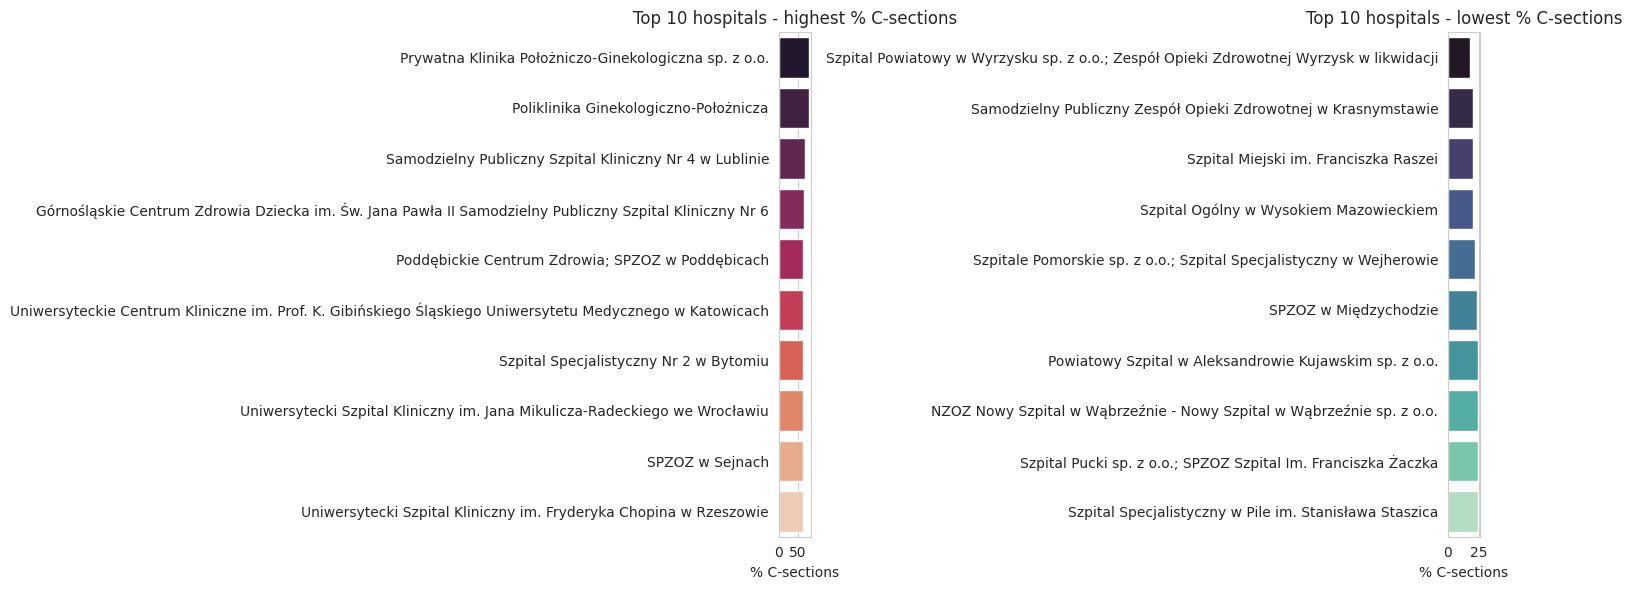

In [16]:
top10 = hospital_stats_filtered.sort_values('pct_cesarean', ascending=False).head(10)
bottom10 = hospital_stats_filtered.sort_values('pct_cesarean', ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=top10, x='pct_cesarean', y='hospital_name', hue='hospital_name',
            palette='rocket', legend=False, ax=axes[0])
axes[0].set_title('Top 10 hospitals - highest % C-sections')
axes[0].set_xlabel('% C-sections')
axes[0].set_ylabel('')

sns.barplot(data=bottom10, x='pct_cesarean', y='hospital_name', hue='hospital_name',
            palette='mako', legend=False, ax=axes[1])
axes[1].set_title('Top 10 hospitals - lowest % C-sections')
axes[1].set_xlabel('% C-sections')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 7. Does hospital size matter?

My idea here was to check if hospitals that do a lot of births per year have a different C-section rate than small ones. I thought maybe bigger hospitals (they probably get more complicated pregnancy cases sent to them) would have a higher rate. Let's see if that's true.

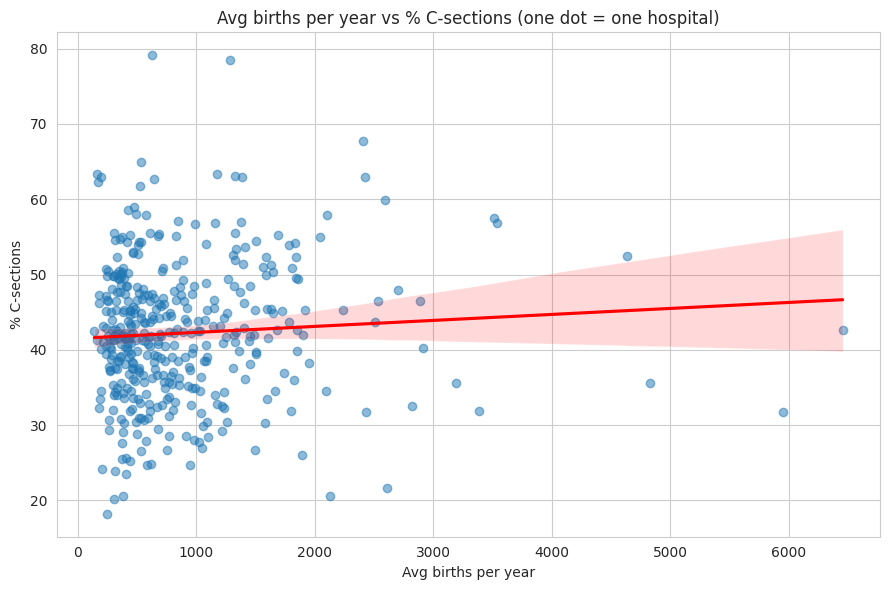

correlation: 0.066


In [17]:
hospital_stats_filtered = hospital_stats_filtered.copy()
years_per_hospital = df.groupby('hospital_id')['year'].nunique()
hospital_stats_filtered['avg_births_per_year'] = hospital_stats_filtered.apply(
    lambda row: row['births_total'] / years_per_hospital[row['hospital_id']], axis=1
)

plt.figure(figsize=(9, 6))
sns.regplot(
    data=hospital_stats_filtered,
    x='avg_births_per_year', y='pct_cesarean',
    scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'}
)

plt.title('Avg births per year vs % C-sections (one dot = one hospital)')
plt.xlabel('Avg births per year')
plt.ylabel('% C-sections')
plt.tight_layout()
plt.show()

correlation = hospital_stats_filtered['avg_births_per_year'].corr(hospital_stats_filtered['pct_cesarean'])
print(f'correlation: {correlation:.3f}')

Correlation is basically close to 0, and the red trend line is almost flat. So my guess was wrong - hospital size doesn't really explain the difference in C-section rate. I found that a bit surprising, honestly. Maybe the differences come more from how each hospital works than from how many births they do.

## 8. Simple model - trend over time

In part 3 there's a clear upward trend, so I tried a simple linear regression to describe it: `% C-sections = a * year + b`. It's a very basic model (just one variable), but it's enough to:
- get a number for how much the rate grows per year on average
- check with R² how well a straight line actually fits the trend
- make a rough guess for next year

In [18]:
X = trend.index.values.reshape(-1, 1)   # year
y = trend['pct_cesarean'].values          # % C-sections

model = LinearRegression()
model.fit(X, y)

yearly_increase = model.coef_[0]
r2 = model.score(X, y)

print(f'average yearly increase: {yearly_increase:.2f} percentage points / year')
print(f'R^2 of the model: {r2:.3f}')

average yearly increase: 0.90 percentage points / year
R^2 of the model: 0.888


prediction for 2026: 51.0% C-sections


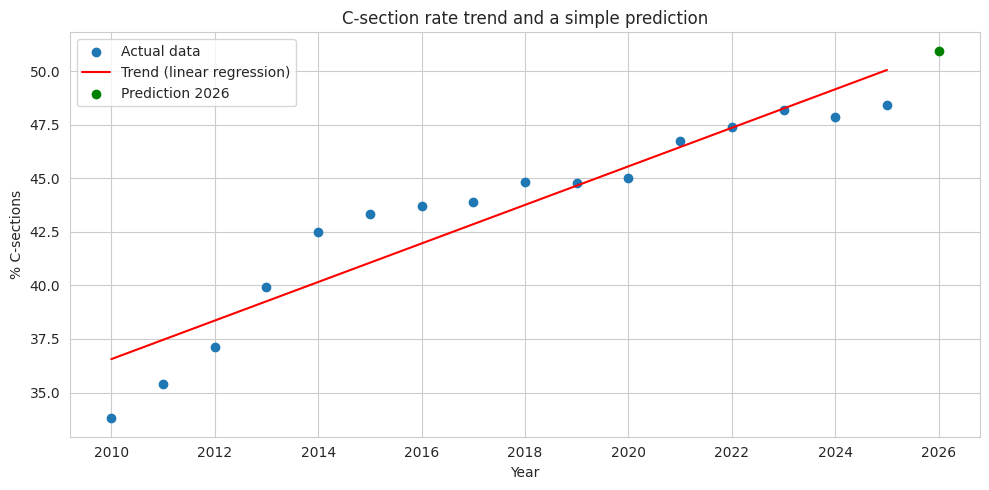

In [19]:
next_year = trend.index.max() + 1
prediction = model.predict([[next_year]])[0]

print(f'prediction for {next_year}: {prediction:.1f}% C-sections')

# plotting real data + the trend line from the model
plt.figure(figsize=(10, 5))
plt.scatter(trend.index, y, label='Actual data')
plt.plot(trend.index, model.predict(X), color='red', label='Trend (linear regression)')
plt.scatter([next_year], [prediction], color='green', zorder=5, label=f'Prediction {next_year}')

plt.title('C-section rate trend and a simple prediction')
plt.xlabel('Year')
plt.ylabel('% C-sections')
plt.legend()
plt.tight_layout()
plt.show()

Note about this model - it's pretty simplified, it basically assumes the trend keeps growing forever in a straight line, which obviously can't be true forever (the % can't go over 100, and at some point it will probably flatten out or even go down, e.g. if guidelines change). So I'm treating this more as "how fast has it been growing recently" rather than a real long-term forecast.

## Summary

- C-section rate in Poland went from about **34%** (2010) to almost **48%** (2025). That's a big, pretty steady increase (~0.9 percentage points per year, R² = 0.89).
- Biggest regional gap: **Podkarpackie** (~51%) vs **Pomorskie** (~32%), almost 20 points apart.
- Hospital size (avg births per year) is **basically not correlated** with the C-section rate (correlation ~0.07) - so the differences probably come from something else, not just how big the hospital is.
- The simple linear trend model fits pretty well (R² = 0.89) and if the trend continues the same way, next year could be around ~51%. Again, this is just showing the recent trend/speed, not a real forecast.

Ideas for later, if I want to extend this project:
- use the KOC column (coordinated perinatal care) and check if hospitals in that program have different rates
- try to predict a hospital's C-section rate using a few features (region, size, year) instead of just the national trend
- compare with C-section rates from other EU countries, if I can find public data